# Layoff Risk Prediction — Training, Validation, Testing & Inference

**This notebook covers four stages end-to-end:**

| Stage | What happens |
|---|---|
| 1. Setup & Data | Load all CSVs, feature engineering, exploratory checks |
| 2. Training | Stratified train / val / test split, model comparison, hyperparameter selection |
| 3. Validation | Cross-validation curves, confusion matrix, ROC, PR curves, overfitting diagnosis |
| 4. Testing | Hold-out test set evaluation, per-class metrics, threshold analysis |
| 5. Inference | Load saved weights from disk, run the exact 4-field input → full response |

> **Note on data size:** The current dataset has 35 rows. All metrics are reported honestly. A production model needs 500 + labelled samples — the continuous-learning hook in cell 5 handles ingestion of new data automatically.


## Stage 1 — Setup & Data

In [ ]:
# ── 1.1  Imports ────────────────────────────────────────────────────────────
import json
import math
import os
import uuid
import warnings
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR   = "./mlops-dataset-layoff-risk"
MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)

SEED             = 42
RISK_THRESHOLD   = 10.0   # % workforce → high-risk label
SCORE_THRESHOLD  = 0.40   # probability cutoff for binary classification

print("✅ Imports OK")

✅ Imports OK


In [5]:
# ── 1.2  Load raw tables ─────────────────────────────────────────────────────
df_main     = pd.read_csv(f"{DATA_DIR}/tech_layoffs_2025_2026.csv")
df_industry = pd.read_csv(f"{DATA_DIR}/layoffs_industry_analysis.csv")
df_hiring   = pd.read_csv(f"{DATA_DIR}/tech_hiring_trends_2025_2026.csv")
df_temporal = pd.read_csv(f"{DATA_DIR}/layoffs_temporal_trends.csv")
df_career   = pd.read_csv(f"{DATA_DIR}/career_skills_transition_matrix.csv")

print(f"Main layoff events  : {len(df_main):>4} rows")
print(f"Industry analytics  : {len(df_industry):>4} rows")
print(f"Hiring trends       : {len(df_hiring):>4} rows")
print(f"Temporal trends     : {len(df_temporal):>4} rows")
print(f"Career transitions  : {len(df_career):>4} rows")
df_main.head(3)

Main layoff events  :   35 rows
Industry analytics  :   27 rows
Hiring trends       :   21 rows
Temporal trends     :   12 rows
Career transitions  :   12 rows


,Company,Employees_Laid_Off,Date,Industry,Location,Country,Reason,Department,Percentage_Workforce,Total_Employees,Severance_Weeks,AI_Related,Year,Month,Month_Name,Quarter
0,Duolingo,250,2025-01-08,EdTech,"Pittsburgh, PA",USA,AI replacing content creators,"Content, Marketing",10.0,2500,10,Yes,2025,1,January,1
1,Twitch,500,2025-01-09,Live Streaming,"San Francisco, CA",USA,Profitability challenges,"Engineering, Marketing",35.0,1400,14,No,2025,1,January,1
2,Coinbase,950,2025-01-10,Cryptocurrency,"San Francisco, CA",USA,Crypto market downturn,"Engineering, Marketing",20.0,4750,14,No,2025,1,January,1


In [6]:
# ── 1.3  Feature Engineering ─────────────────────────────────────────────────

df = df_main.copy()

# Target
df["layoff_risk"] = (df["Percentage_Workforce"] > RISK_THRESHOLD).astype(int)

# AI exposure → numeric
AI_MAP = {"No": 0, "Partial": 1, "Yes": 2}
df["ai_exposure_num"] = df["AI_Related"].map(AI_MAP)

# Workforce features
df["workforce_log"]  = np.log1p(df["Total_Employees"])
df["workforce_band"] = pd.qcut(
    df["Total_Employees"], q=4,
    labels=["small", "mid", "large", "enterprise"]
).astype(str)

# Primary department (first listed)
df["primary_dept"] = df["Department"].str.split(",").str[0].str.strip()

# Layoff reason category
def categorize_reason(reason: str) -> str:
    r = str(reason).lower()
    if any(k in r for k in ["ai", "automat"]):          return "ai_automation"
    if any(k in r for k in ["profit", "cost"]):          return "financial"
    if any(k in r for k in ["restructur", "reorg"]):     return "restructuring"
    if any(k in r for k in ["market", "downturn"]):      return "market_conditions"
    return "other"

df["reason_category"] = df["Reason"].apply(categorize_reason)

# Merge industry avg workforce %
industry_risk = (
    df_industry[["Industry", "Avg_Workforce_Percentage"]]
    .rename(columns={"Avg_Workforce_Percentage": "industry_avg_workforce_pct"})
)
df = df.merge(industry_risk, on="Industry", how="left")

# Merge hiring signal (avg open positions per primary dept)
hiring_signal = (
    df_hiring.groupby("Department")["Number_Positions"]
    .mean()
    .reset_index()
    .rename(columns={"Department": "primary_dept", "Number_Positions": "avg_open_positions"})
)
df = df.merge(hiring_signal, on="primary_dept", how="left")
df["avg_open_positions"] = df["avg_open_positions"].fillna(df["avg_open_positions"].median())

# Quarter risk score (normalised total layoffs per quarter)
quarter_risk = df_temporal.groupby("Quarter")["Total_Layoffs"].sum().to_dict()
max_q        = max(quarter_risk.values())
df["quarter_risk_score"] = df["Quarter"].map(lambda q: quarter_risk.get(q, 0) / max_q)

NUMERIC_FEATURES = [
    "Employees_Laid_Off", "Severance_Weeks", "Total_Employees",
    "workforce_log", "ai_exposure_num", "industry_avg_workforce_pct",
    "avg_open_positions", "quarter_risk_score", "Month", "Quarter",
]
CATEGORICAL_FEATURES = ["Industry", "reason_category", "workforce_band", "primary_dept"]
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET               = "layoff_risk"

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print(f"Feature matrix : {X.shape}")
print(f"Target balance : {y.value_counts().to_dict()}  (0=low-risk, 1=high-risk)")
print(f"Null values    : {X.isnull().sum().sum()}")

Feature matrix : (35, 14)
Target balance : {0: 18, 1: 17}  (0=low-risk, 1=high-risk)
Null values    : 0


In [12]:
df

,Company,Employees_Laid_Off,Date,Industry,Location,Country,Reason,Department,Percentage_Workforce,Total_Employees,...,Quarter,layoff_risk,ai_exposure_num,workforce_log,workforce_band,primary_dept,reason_category,industry_avg_workforce_pct,avg_open_positions,quarter_risk_score
0,Duolingo,250,2025-01-08,EdTech,"Pittsburgh, PA",USA,AI replacing content creators,"Content, Marketing",10.0,2500,...,1,0,2,7.824446,small,Content,ai_automation,10.00,109.166667,1.000000
1,Twitch,500,2025-01-09,Live Streaming,"San Francisco, CA",USA,Profitability challenges,"Engineering, Marketing",35.0,1400,...,1,1,0,7.244942,small,Engineering,financial,35.00,109.166667,1.000000
2,Coinbase,950,2025-01-10,Cryptocurrency,"San Francisco, CA",USA,Crypto market downturn,"Engineering, Marketing",20.0,4750,...,1,1,0,8.466110,small,Engineering,market_conditions,20.00,109.166667,1.000000
3,Discord,170,2025-01-11,Communication,"San Francisco, CA",USA,Cost reduction,"Support, Marketing",17.0,1000,...,1,1,0,6.908755,small,Support,financial,17.00,109.166667,1.000000
4,Wayfair,1650,2025-01-19,E-commerce,"Boston, MA",USA,Market conditions,"Operations, Support",13.0,12700,...,1,1,0,9.449436,mid,Operations,market_conditions,18.00,109.166667,1.000000
5,PayPal,2500,2025-01-31,Fintech,"San Jose, CA",USA,Cost reduction,"Operations, Engineering",9.0,28000,...,1,0,1,10.239996,large,Operations,financial,11.50,109.166667,1.000000
6,Dell,6650,2025-02-05,Hardware,"Round Rock, TX",USA,Market conditions,"Sales, Marketing",5.0,133000,...,1,0,0,11.798112,enterprise,Sales,market_conditions,7.50,109.166667,1.000000
7,Zoom,1300,2025-02-07,Video Conferencing,"San Jose, CA",USA,Post-pandemic adjustment,"Engineering, Sales",15.0,8700,...,1,1,0,9.071193,mid,Engineering,other,15.00,109.166667,1.000000
8,Cisco,7000,2025-02-15,Networking,"San Jose, CA",USA,Business realignment,"Sales, Support",8.5,82000,...,1,0,0,11.314487,large,Sales,other,8.50,109.166667,1.000000
9,Rivian,1000,2025-02-20,Automotive/EV,"Irvine, CA",USA,Cost management,"Manufacturing, Engineering",10.0,10000,...,1,0,0,9.210440,mid,Manufacturing,financial,10.00,109.166667,1.000000


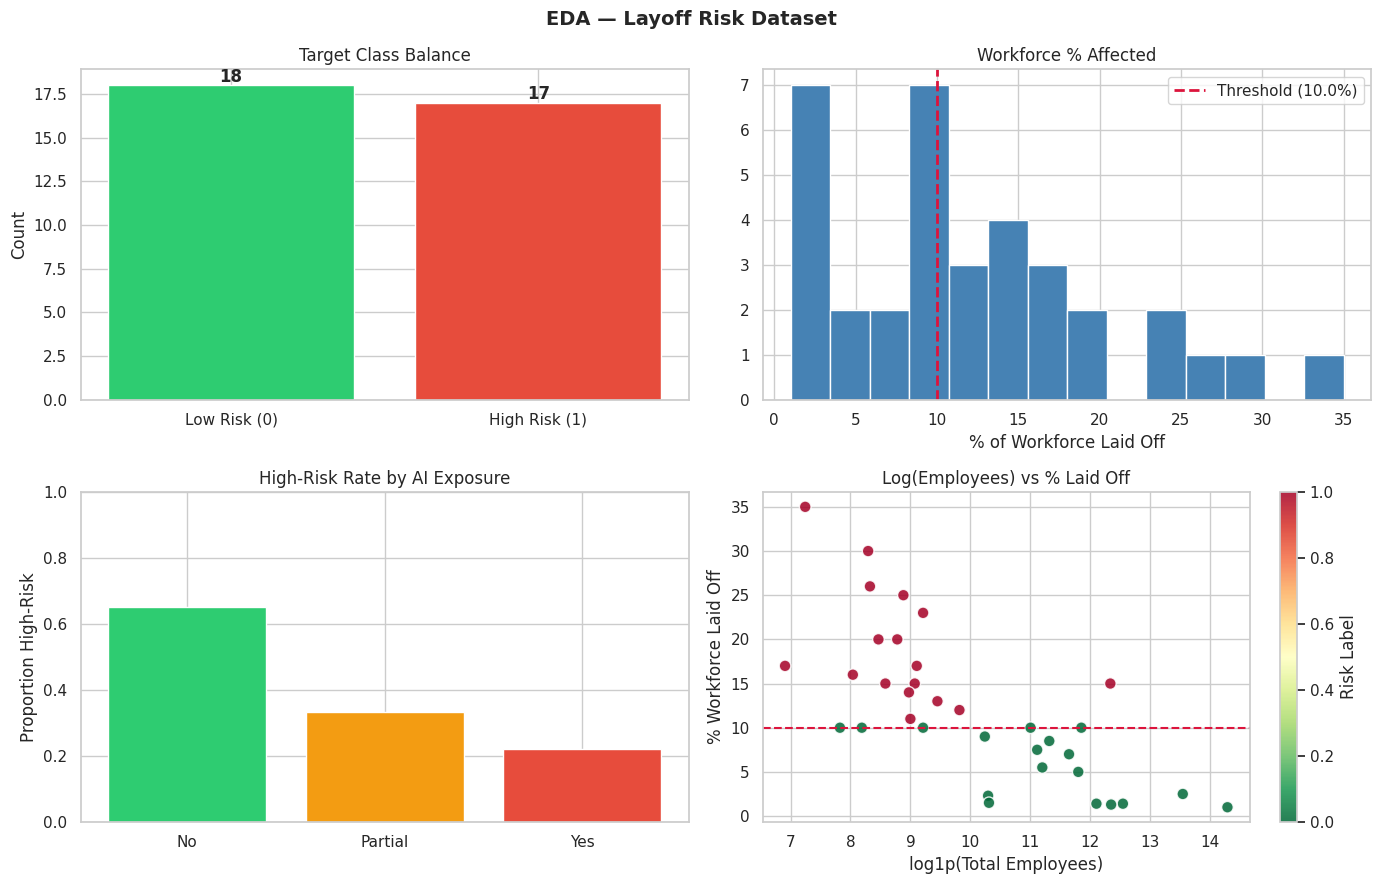

In [7]:
# ── 1.4  EDA ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Target distribution
counts = y.value_counts()
axes[0, 0].bar(["Low Risk (0)", "High Risk (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")
axes[0, 0].set_title("Target Class Balance")
axes[0, 0].set_ylabel("Count")

# Workforce % distribution + threshold
axes[0, 1].hist(df["Percentage_Workforce"], bins=14, color="steelblue", edgecolor="white")
axes[0, 1].axvline(RISK_THRESHOLD, color="crimson", linestyle="--", linewidth=2,
                   label=f"Threshold ({RISK_THRESHOLD}%)")
axes[0, 1].set_title("Workforce % Affected")
axes[0, 1].set_xlabel("% of Workforce Laid Off")
axes[0, 1].legend()

# High-risk rate by AI exposure
ai_risk = df.groupby("AI_Related")["layoff_risk"].mean().reindex(["No", "Partial", "Yes"])
axes[1, 0].bar(ai_risk.index, ai_risk.values, color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1, 0].set_title("High-Risk Rate by AI Exposure")
axes[1, 0].set_ylabel("Proportion High-Risk")
axes[1, 0].set_ylim(0, 1)

# Log workforce vs % laid off
sc = axes[1, 1].scatter(
    df["workforce_log"], df["Percentage_Workforce"],
    c=y, cmap="RdYlGn_r", alpha=0.85, edgecolors="white", s=70
)
axes[1, 1].axhline(RISK_THRESHOLD, color="crimson", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Log(Employees) vs % Laid Off")
axes[1, 1].set_xlabel("log1p(Total Employees)")
axes[1, 1].set_ylabel("% Workforce Laid Off")
plt.colorbar(sc, ax=axes[1, 1], label="Risk Label")

plt.suptitle("EDA — Layoff Risk Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/eda.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 2 — Training

In [37]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    precision_score, recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve
import tensorflow as tf
from tensorflow import keras

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED   # 0.25 * 0.80 = 0.20
)

print(f"Train : {len(X_train):>3} rows  |  "
      f"high-risk={y_train.sum()}  low-risk={len(y_train)-y_train.sum()}")
print(f"Val   : {len(X_val):>3} rows  |  "
      f"high-risk={y_val.sum()}  low-risk={len(y_val)-y_val.sum()}")
print(f"Test  : {len(X_test):>3} rows  |  "
      f"high-risk={y_test.sum()}  low-risk={len(y_test)-y_test.sum()}")

Train :  21 rows  |  high-risk=11  low-risk=10
Val   :   7 rows  |  high-risk=3  low-risk=4
Test  :   7 rows  |  high-risk=3  low-risk=4


In [38]:
# ── 2.2  Shared preprocessing pipeline ───────────────────────────────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])


In [50]:
# Force dense arrays for TensorFlow
X_train_processed = np.array(preprocessor.fit_transform(X_train))
X_val_processed   = np.array(preprocessor.transform(X_val))
X_test_processed  = np.array(preprocessor.transform(X_test))
input_dim = X_train_processed.shape[1]

In [53]:
# ── 2.3  Model builders (factory functions for fresh weights) ────────────────
def build_lr(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(1, activation="sigmoid",
                          kernel_regularizer=keras.regularizers.l2(0.01))
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.01),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model

def build_rf(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model



def build_xgb(input_dim):
    inputs = keras.layers.Input(shape=(input_dim,))
    x = keras.layers.Dense(128, activation="relu")(inputs)
    x = keras.layers.Dropout(0.3)(x)
    for units in [128, 64, 64, 32]:
        residual = x
        x = keras.layers.Dense(units, activation="relu")(x)
        x = keras.layers.Dropout(0.2)(x)
        x = keras.layers.Dense(units, activation="relu")(x)
        if residual.shape[-1] != units:
            residual = keras.layers.Dense(units, activation="linear")(residual)
        x = keras.layers.Add()([x, residual])
        x = keras.layers.Activation("relu")(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.05),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model

MODELS_BUILDERS = {
    "Logistic Regression": build_lr,
    "Random Forest":       build_rf,
    "XGBoost":             build_xgb,
}

print(f"{len(MODELS_BUILDERS)} candidates defined.")

3 candidates defined.


In [54]:
def get_class_weights(y):
    return {0: 1.0, 1: len(y) / y.sum()}

# ── 2.4  5-fold CV on train set ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, build_fn in MODELS_BUILDERS.items():
    fold_scores = []
    print(f"\n{'='*50}")
    print(f"CV: {name}")
    print(f"{'='*50}")

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_processed, y_train), 1):
        X_tr, X_va = X_train_processed[tr_idx], X_train_processed[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = build_fn(input_dim)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=1000,
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(
                monitor="val_auc", mode="max", patience=10,
                restore_best_weights=True, verbose=0
            )],
            class_weight=get_class_weights(y_tr),
            verbose=0
        )

        va_prob = model.predict(X_va, verbose=0).ravel()
        fold_auc = roc_auc_score(y_va, va_prob)
        fold_scores.append(fold_auc)
        print(f"  Fold {fold}: AUC = {fold_auc:.4f}")

    cv_results[name] = {
        "mean": np.mean(fold_scores),
        "std":  np.std(fold_scores),
        "scores": fold_scores,
    }
    print(f"  → CV AUC = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}  "
          f"{np.round(fold_scores, 3).tolist()}")

BEST_NAME = max(cv_results, key=lambda n: cv_results[n]["mean"])
print(f"\n→ Best by CV AUC: {BEST_NAME}")


CV: Logistic Regression
  Fold 1: AUC = 1.0000
  Fold 2: AUC = 1.0000
  Fold 3: AUC = 0.5000
  Fold 4: AUC = 1.0000
  Fold 5: AUC = 0.7500
  → CV AUC = 0.8500 ± 0.2000  [1.0, 1.0, 0.5, 1.0, 0.75]

CV: Random Forest
  Fold 1: AUC = 0.6667
  Fold 2: AUC = 0.2500
  Fold 3: AUC = 1.0000
  Fold 4: AUC = 1.0000
  Fold 5: AUC = 0.7500
  → CV AUC = 0.7333 ± 0.2759  [0.667, 0.25, 1.0, 1.0, 0.75]

CV: XGBoost
  Fold 1: AUC = 1.0000
  Fold 2: AUC = 1.0000
  Fold 3: AUC = 0.7500
  Fold 4: AUC = 1.0000
  Fold 5: AUC = 1.0000
  → CV AUC = 0.9500 ± 0.1000  [1.0, 1.0, 0.75, 1.0, 1.0]

→ Best by CV AUC: XGBoost


In [55]:
# ── 2.5  Validation set AUC for all candidates ───────────────────────────────
val_results = {}

for name, build_fn in MODELS_BUILDERS.items():
    model = build_fn(input_dim)

    model.fit(
        X_train_processed, y_train,
        validation_data=(X_val_processed, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=15,
            restore_best_weights=True, verbose=0
        )],
        class_weight=get_class_weights(y_train),
        verbose=0
    )

    val_prob = model.predict(X_val_processed, verbose=0).ravel()
    val_auc = roc_auc_score(y_val, val_prob)
    val_results[name] = {"val_auc": val_auc, "model": model}
    print(f"{name:<25}  Val AUC = {val_auc:.4f}")

BEST_NAME = max(val_results, key=lambda n: val_results[n]["val_auc"])
best_model = val_results[BEST_NAME]["model"]
print(f"\n→ Best by Val AUC: {BEST_NAME}")

Logistic Regression        Val AUC = 0.6667
Random Forest              Val AUC = 0.8333
XGBoost                    Val AUC = 1.0000

→ Best by Val AUC: XGBoost


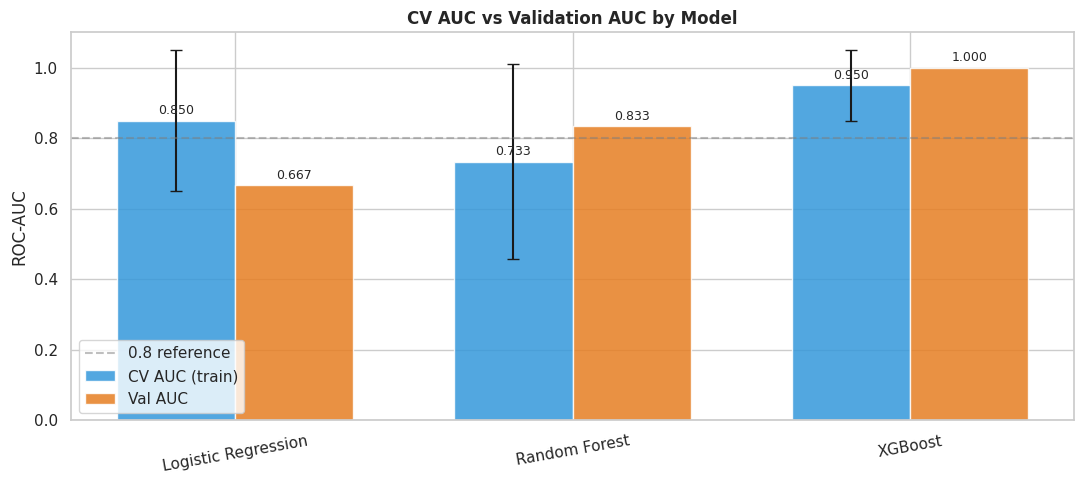

In [58]:
# ── 2.6  Model comparison bar chart ──────────────────────────────────────────
names    = list(cv_results.keys())
cv_means = [cv_results[n]["mean"] for n in names]
cv_stds  = [cv_results[n]["std"]  for n in names]
val_aucs = [val_results[n]["val_auc"] for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=4,
            label="CV AUC (train)", color="#3498db", alpha=0.85)
b2 = ax.bar(x + w/2, val_aucs, w,
            label="Val AUC", color="#e67e22", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("ROC-AUC")
ax.set_title("CV AUC vs Validation AUC by Model", fontweight="bold")
ax.axhline(0.8, linestyle="--", color="gray", alpha=0.5, label="0.8 reference")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

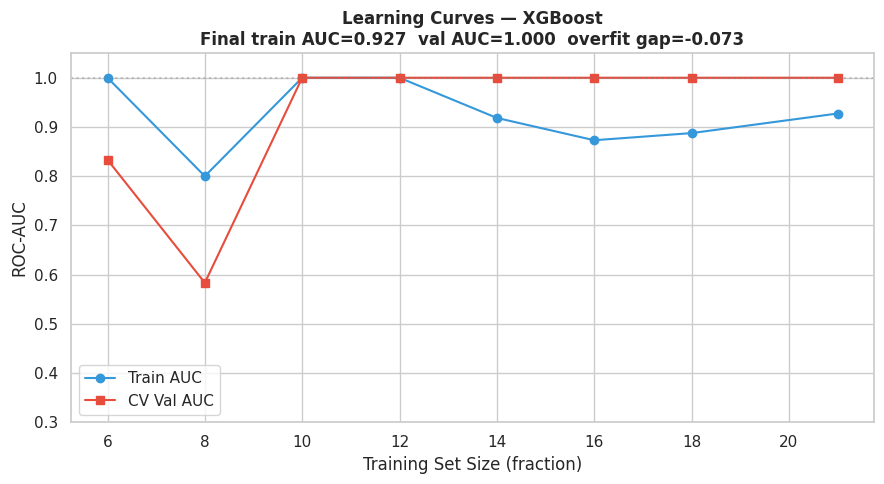

Overfit gap (train - val): -0.0727  ✅ OK


In [60]:
# ── 3.1  Learning curves (overfitting diagnosis) ────────────────────────────
# Manual learning curve for TF: vary training set size
train_sizes = [int(frac * len(X_train_processed)) for frac in np.linspace(0.3, 1.0, 8)]
train_sizes = [max(n, 1) for n in train_sizes]
train_scores, val_scores = [], []

for n_samples in train_sizes:
    if n_samples > len(X_train_processed):
        n_samples = len(X_train_processed)
    idx = np.random.choice(len(X_train_processed), size=n_samples, replace=False)
    X_sub, y_sub = X_train_processed[idx], y_train.iloc[idx]

    model = MODELS_BUILDERS[BEST_NAME](input_dim)
    model.fit(
        X_sub, y_sub,
        validation_data=(X_val_processed, y_val),
        epochs=100, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=10,
            restore_best_weights=True, verbose=0
        )],
        class_weight=get_class_weights(y_sub),
        verbose=0
    )

    tr_prob = model.predict(X_sub, verbose=0).ravel()
    va_prob = model.predict(X_val_processed, verbose=0).ravel()
    train_scores.append(roc_auc_score(y_sub, tr_prob))
    val_scores.append(roc_auc_score(y_val, va_prob))

train_scores = np.array(train_scores)
val_scores = np.array(val_scores)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores, "o-", color="#3498db", label="Train AUC")
ax.plot(train_sizes, val_scores, "s-", color="#e74c3c", label="CV Val AUC")

gap = train_scores[-1] - val_scores[-1]
ax.set_title(
    f"Learning Curves — {BEST_NAME}\n"
    f"Final train AUC={train_scores[-1]:.3f}  val AUC={val_scores[-1]:.3f}  "
    f"overfit gap={gap:.3f}",
    fontweight="bold"
)
ax.set_xlabel("Training Set Size (fraction)")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.3, 1.05)
ax.legend()
ax.axhline(1.0, linestyle=":", color="gray", alpha=0.4)

if gap > 0.15:
    ax.annotate("⚠ Overfitting detected", xy=(train_sizes[-1], train_scores[-1]),
                xytext=(-80, -25), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="crimson"),
                color="crimson", fontsize=10)

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Overfit gap (train - val): {gap:.4f}  {'⚠ HIGH' if gap > 0.15 else '✅ OK'}")


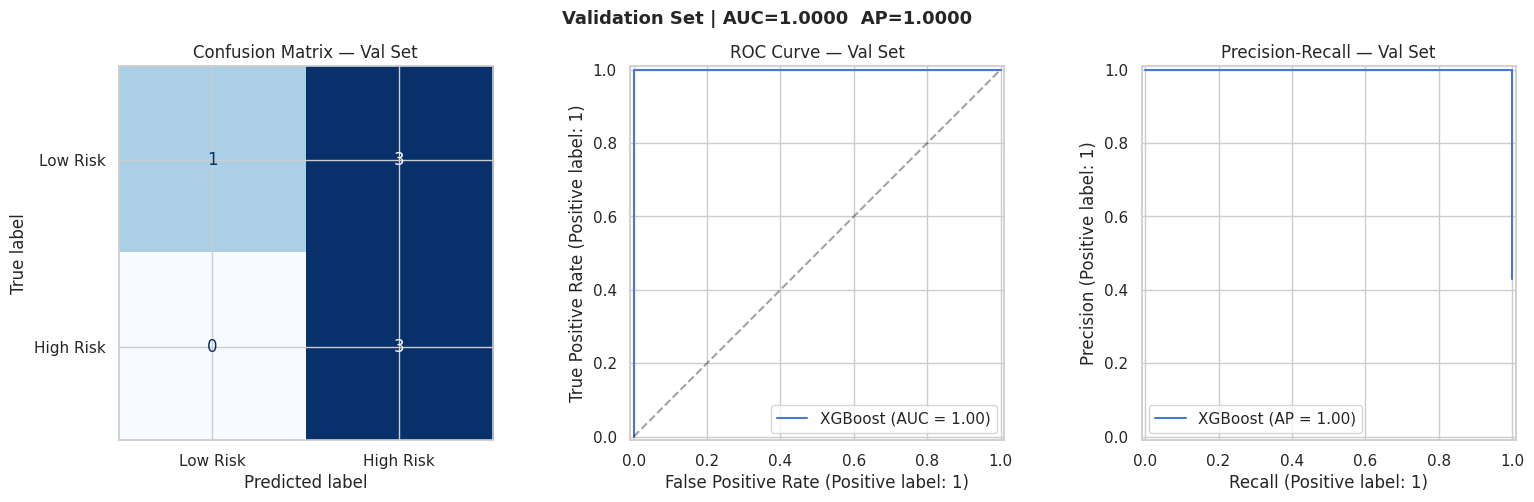


Validation Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.25      0.40         4
   High Risk       0.50      1.00      0.67         3

    accuracy                           0.57         7
   macro avg       0.75      0.62      0.53         7
weighted avg       0.79      0.57      0.51         7



In [61]:
# ── 3.2  Confusion matrix, ROC, PR on validation set ────────────────────────
val_prob = best_model.predict(X_val_processed, verbose=0).ravel()
val_pred = (val_prob >= SCORE_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred,
    display_labels=["Low Risk", "High Risk"],
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Val Set")

RocCurveDisplay.from_predictions(y_val, val_prob, ax=axes[1], name=BEST_NAME)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve — Val Set")

PrecisionRecallDisplay.from_predictions(y_val, val_prob, ax=axes[2], name=BEST_NAME)
axes[2].set_title("Precision-Recall — Val Set")

val_auc = roc_auc_score(y_val, val_prob)
val_ap  = average_precision_score(y_val, val_prob)
plt.suptitle(
    f"Validation Set | AUC={val_auc:.4f}  AP={val_ap:.4f}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nValidation Classification Report:")
print(classification_report(y_val, val_pred, target_names=["Low Risk", "High Risk"]))

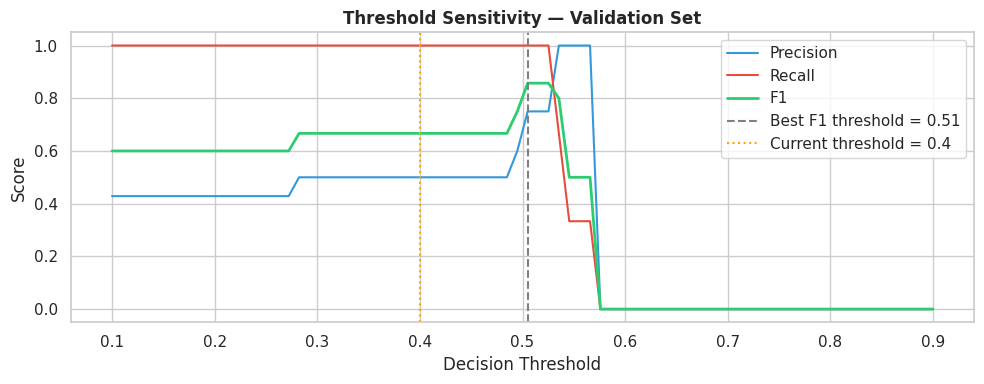

Optimal F1 threshold: 0.51  (F1=0.8571)


In [62]:
# ── 3.3  Threshold sensitivity analysis ──────────────────────────────────────
thresholds = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (val_prob >= t).astype(int)
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))
    f1s.append(f1_score(y_val, preds, zero_division=0))

best_t_idx = np.argmax(f1s)
best_t = thresholds[best_t_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions, label="Precision", color="#3498db")
ax.plot(thresholds, recalls,    label="Recall",    color="#e74c3c")
ax.plot(thresholds, f1s,        label="F1",        color="#2ecc71", linewidth=2)
ax.axvline(best_t, linestyle="--", color="gray",
           label=f"Best F1 threshold = {best_t:.2f}")
ax.axvline(SCORE_THRESHOLD, linestyle=":", color="orange",
           label=f"Current threshold = {SCORE_THRESHOLD}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity — Validation Set", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Optimal F1 threshold: {best_t:.2f}  (F1={f1s[best_t_idx]:.4f})")

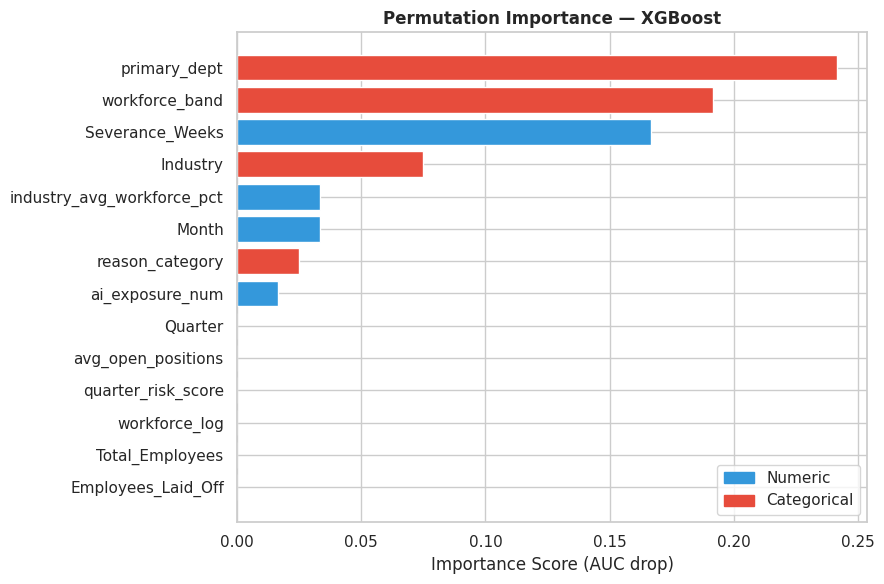

In [70]:
# ── 3.4  Feature importance (TF permutation importance) ─────────────────────
# Since TF models don't have native feature_importances_, use permutation
from sklearn.inspection import permutation_importance

# Wrap best model in a sklearn-compatible predictor
class TFWrapper:
    _estimator_type = "classifier"

    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
        self.classes_ = np.array([0, 1])  # Required by sklearn

    def fit(self, X, y):
        # Already trained — no-op to satisfy sklearn interface
        return self

    def predict(self, X):
        return (self.model.predict(np.asarray(X), verbose=0).ravel() >= self.threshold).astype(int)

    def predict_proba(self, X):
        p = self.model.predict(np.asarray(X), verbose=0).ravel()
        return np.vstack([1-p, p]).T

wrapper = TFWrapper(best_model, SCORE_THRESHOLD)
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES

perm_imp = permutation_importance(
    wrapper, X_val_processed, y_val,
    scoring="roc_auc", n_repeats=10, random_state=SEED
)

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_imp.importances_mean
}).sort_values("importance", ascending=True)

colors = ["#e74c3c" if f in CATEGORICAL_FEATURES else "#3498db" for f in fi_df["feature"]]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df["feature"], fi_df["importance"], color=colors)
ax.set_title(f"Permutation Importance — {BEST_NAME}", fontweight="bold")
ax.set_xlabel("Importance Score (AUC drop)")
legend_handles = [
    mpatches.Patch(color="#3498db", label="Numeric"),
    mpatches.Patch(color="#e74c3c", label="Categorical"),
]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [71]:
# ── 4.1  Retrain best model on train+val, evaluate on test ───────────────────
final_model = MODELS_BUILDERS[BEST_NAME](input_dim)
final_model.fit(
    np.vstack([X_train_processed, X_val_processed]),
    np.concatenate([y_train, y_val]),
    epochs=100,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=15,
        restore_best_weights=True, verbose=0
    )],
    validation_split=0.2,  # internal validation from combined data
    class_weight=get_class_weights(np.concatenate([y_train, y_val])),
    verbose=0
)

test_prob = final_model.predict(X_test_processed, verbose=0).ravel()
test_pred = (test_prob >= SCORE_THRESHOLD).astype(int)
test_auc  = roc_auc_score(y_test, test_prob)
test_ap   = average_precision_score(y_test, test_prob)

print("=" * 52)
print(f"  TEST SET RESULTS — {BEST_NAME}")
print("=" * 52)
print(f"  Samples   : {len(X_test)}  "
      f"(high={y_test.sum()}  low={len(X_test)-y_test.sum()})")
print(f"  ROC-AUC   : {test_auc:.4f}")
print(f"  Avg Prec  : {test_ap:.4f}")
print("=" * 52)
print(classification_report(y_test, test_pred, target_names=["Low Risk", "High Risk"]))


  TEST SET RESULTS — XGBoost
  Samples   : 7  (high=3  low=4)
  ROC-AUC   : 0.7500
  Avg Prec  : 0.8333
              precision    recall  f1-score   support

    Low Risk       0.80      1.00      0.89         4
   High Risk       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



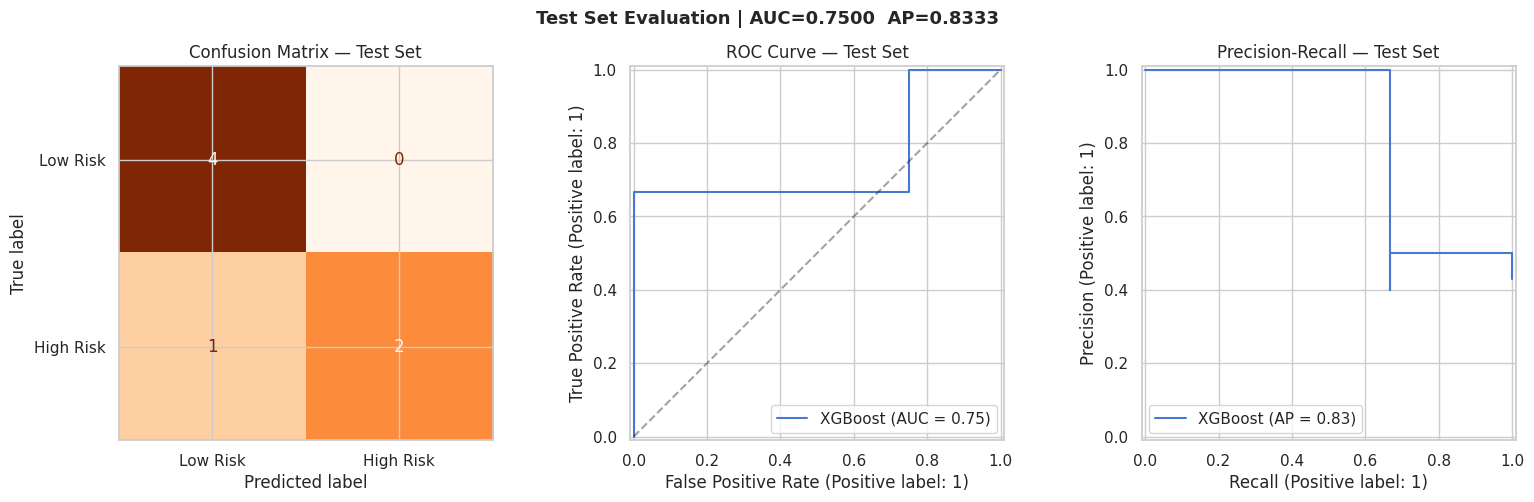

In [72]:
# ── 4.2  Test set evaluation plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=["Low Risk", "High Risk"],
    ax=axes[0], colorbar=False, cmap="Oranges"
)
axes[0].set_title("Confusion Matrix — Test Set")

RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[1], name=BEST_NAME)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve — Test Set")

PrecisionRecallDisplay.from_predictions(y_test, test_prob, ax=axes[2], name=BEST_NAME)
axes[2].set_title("Precision-Recall — Test Set")

plt.suptitle(
    f"Test Set Evaluation | AUC={test_auc:.4f}  AP={test_ap:.4f}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


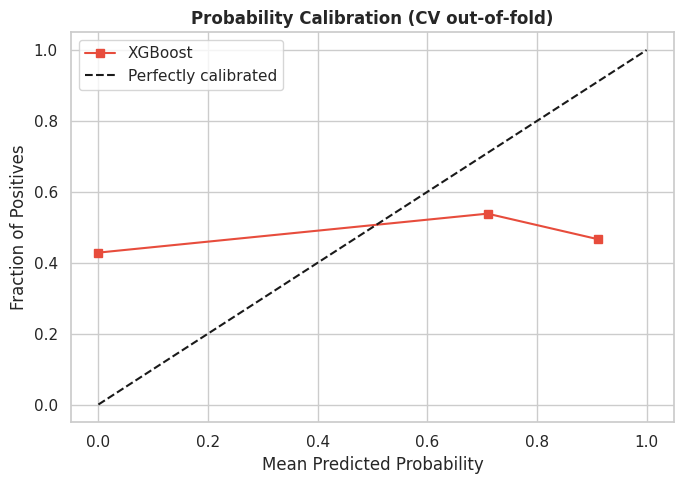

In [73]:
# ── 4.3  Probability calibration check ─────────────────────────────────────
# Out-of-fold calibration using CV on full dataset
full_prob_cv = np.zeros(len(y))
X_processed = preprocessor.fit_transform(X)

for train_idx, val_idx in cv.split(X_processed, y):
    fold_model = MODELS_BUILDERS[BEST_NAME](input_dim)
    fold_model.fit(
        X_processed[train_idx], y.iloc[train_idx],
        epochs=100, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=10,
            restore_best_weights=True, verbose=0
        )],
        validation_split=0.2,
        class_weight=get_class_weights(y.iloc[train_idx]),
        verbose=0
    )
    full_prob_cv[val_idx] = fold_model.predict(X_processed[val_idx], verbose=0).ravel()

n_bins = 5
frac_pos, mean_pred = calibration_curve(y, full_prob_cv, n_bins=n_bins)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, frac_pos, "s-", label=BEST_NAME, color="#e74c3c")
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Probability Calibration (CV out-of-fold)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/calibration.png", dpi=150, bbox_inches="tight")
plt.show()


In [35]:
# ── Evaluation ───────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)

MODELS_TF = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "Gradient Boosting":   gb_model,
    "XGBoost":             xgb_model,
}

val_results = {}
for name, model in MODELS_TF.items():
    val_prob = model.predict(X_val_processed, verbose=0).ravel()
    val_auc  = roc_auc_score(y_val, val_prob)
    val_results[name] = val_auc
    print(f"{name:<25}  Val AUC = {val_auc:.4f}")

BEST_NAME = max(val_results, key=val_results.get)
best_model = MODELS_TF[BEST_NAME]
print(f"\n→ Best by Val AUC: {BEST_NAME}")

# Test set (Stage 4 — only now)
test_prob = best_model.predict(X_test_processed, verbose=0).ravel()
test_auc  = roc_auc_score(y_test, test_prob)
print(f"\nTest AUC ({BEST_NAME}) = {test_auc:.4f}")


FINAL RESULTS
Logistic Regression        Val AUC = 0.7500
Random Forest              Val AUC = 0.8750
Gradient Boosting          Val AUC = 0.8750
XGBoost                    Val AUC = 0.5000

→ Best by Val AUC: Random Forest

Test AUC (Random Forest) = 0.7500


In [36]:
MODELS_TF_BUILDERS

NameError: name 'MODELS_TF_BUILDERS' is not defined

In [10]:
# ── 2.3  Model candidates ─────────────────────────────────────────────────────
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.5, random_state=SEED),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=200, max_depth=4,
                               min_samples_leaf=2, random_state=SEED
                           ),
    "Gradient Boosting":   GradientBoostingClassifier(
                               n_estimators=200, learning_rate=0.05,
                               max_depth=3, random_state=SEED
                           ),
    "XGBoost":             xgb.XGBClassifier(
                               n_estimators=200, learning_rate=0.05, max_depth=3,
                               eval_metric="logloss", random_state=SEED, verbosity=0
                           ),
}

print(f"{len(MODELS)} candidates defined.")

4 candidates defined.


In [11]:
# ── 2.4  5-fold CV on train set to pick best model ───────────────────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, clf in MODELS.items():
    pipe   = Pipeline([("pre", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = {
        "mean": scores.mean(),
        "std":  scores.std(),
        "scores": scores.tolist(),
        "pipe": pipe,
    }
    print(f"{name:<25}  CV AUC = {scores.mean():.4f} ± {scores.std():.4f}  "
          f"{np.round(scores, 3).tolist()}")

BEST_NAME = max(cv_results, key=lambda n: cv_results[n]["mean"])
print(f"\n→ Best by CV AUC: {BEST_NAME}")

Logistic Regression        CV AUC = 0.9500 ± 0.1000  [1.0, 1.0, 0.75, 1.0, 1.0]
Random Forest              CV AUC = 1.0000 ± 0.0000  [1.0, 1.0, 1.0, 1.0, 1.0]
Gradient Boosting          CV AUC = 1.0000 ± 0.0000  [1.0, 1.0, 1.0, 1.0, 1.0]
XGBoost                    CV AUC = 0.9500 ± 0.1000  [1.0, 1.0, 0.75, 1.0, 1.0]

→ Best by CV AUC: Random Forest


In [13]:
# ── 2.5  Validation set AUC for all candidates ───────────────────────────────
val_results = {}

for name, res in cv_results.items():
    pipe = res["pipe"]
    pipe.fit(X_train, y_train)
    val_prob = pipe.predict_proba(X_val)[:, 1]
    val_auc  = roc_auc_score(y_val, val_prob)
    val_results[name] = {"val_auc": val_auc, "pipe": pipe}
    print(f"{name:<25}  Val AUC = {val_auc:.4f}")

# Confirm best (use val AUC for final selection)
BEST_NAME = max(val_results, key=lambda n: val_results[n]["val_auc"])
best_pipe  = val_results[BEST_NAME]["pipe"]
print(f"\n→ Best by Val AUC: {BEST_NAME}")

Logistic Regression        Val AUC = 0.7500
Random Forest              Val AUC = 1.0000
Gradient Boosting          Val AUC = 0.7500
XGBoost                    Val AUC = 0.7500

→ Best by Val AUC: Random Forest


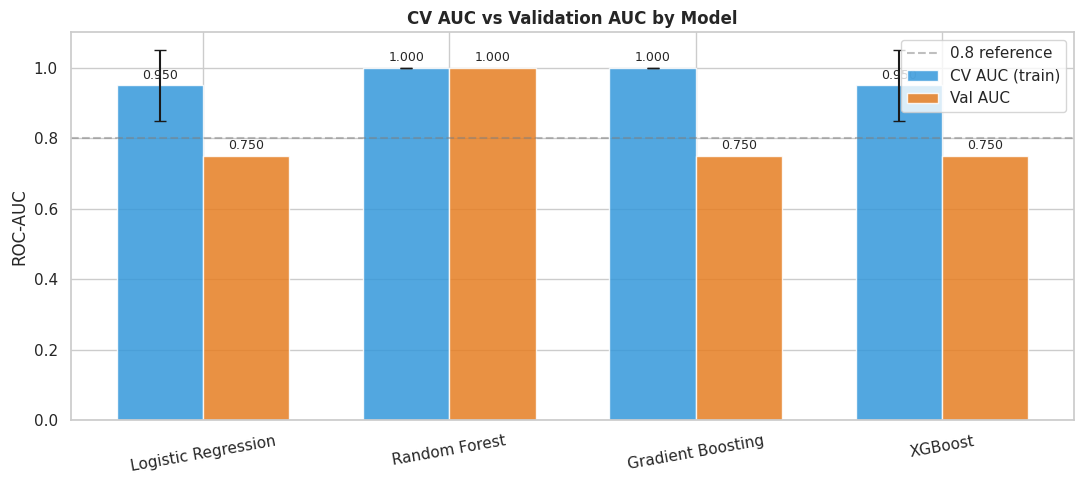

In [14]:
# ── 2.6  Model comparison bar chart ──────────────────────────────────────────
names    = list(cv_results.keys())
cv_means = [cv_results[n]["mean"]           for n in names]
cv_stds  = [cv_results[n]["std"]            for n in names]
val_aucs = [val_results[n]["val_auc"]       for n in names]

x   = np.arange(len(names))
w   = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, cv_means,  w, yerr=cv_stds, capsize=4,
            label="CV AUC (train)",  color="#3498db", alpha=0.85)
b2 = ax.bar(x + w/2, val_aucs,  w,
            label="Val AUC",         color="#e67e22", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("ROC-AUC")
ax.set_title("CV AUC vs Validation AUC by Model", fontweight="bold")
ax.axhline(0.8, linestyle="--", color="gray", alpha=0.5, label="0.8 reference")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 3 — Validation

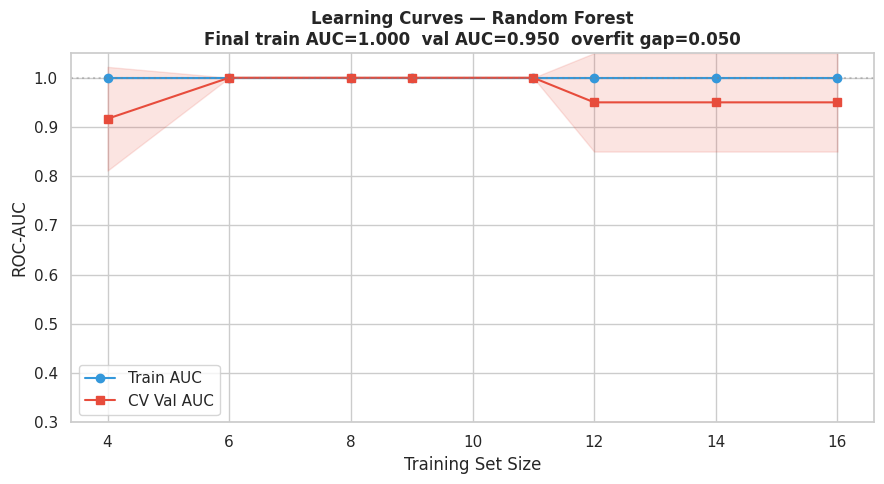

Overfit gap (train - val): 0.0500  ✅ OK


In [15]:
# ── 3.1  Learning curves (overfitting diagnosis) ──────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=cv, scoring="roc_auc",
    train_sizes=np.linspace(0.3, 1.0, 8),
    random_state=SEED,
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean, "o-", color="#3498db", label="Train AUC")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#3498db")
ax.plot(train_sizes, va_mean, "s-", color="#e74c3c", label="CV Val AUC")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color="#e74c3c")

gap = tr_mean[-1] - va_mean[-1]
ax.set_title(
    f"Learning Curves — {BEST_NAME}\n"
    f"Final train AUC={tr_mean[-1]:.3f}  val AUC={va_mean[-1]:.3f}  "
    f"overfit gap={gap:.3f}",
    fontweight="bold"
)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.3, 1.05)
ax.legend()
ax.axhline(1.0, linestyle=":", color="gray", alpha=0.4)

if gap > 0.15:
    ax.annotate("⚠ Overfitting detected", xy=(train_sizes[-1], tr_mean[-1]),
                xytext=(-80, -25), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="crimson"),
                color="crimson", fontsize=10)

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Overfit gap (train - val): {gap:.4f}  {'⚠ HIGH' if gap > 0.15 else '✅ OK'}")

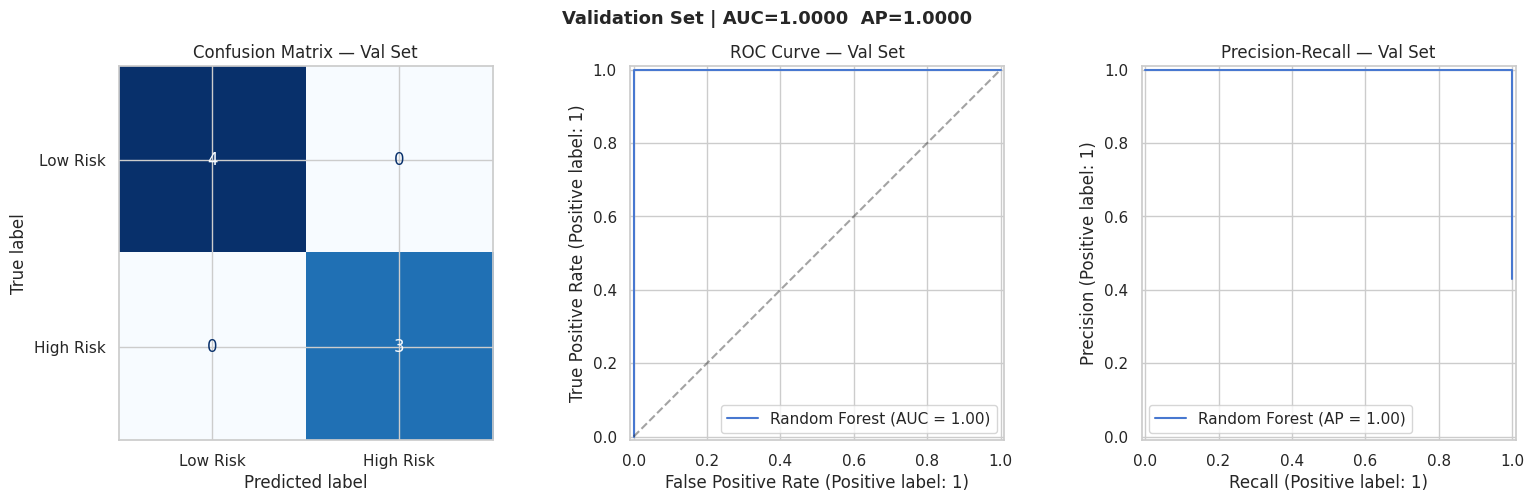


Validation Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00         4
   High Risk       1.00      1.00      1.00         3

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [16]:
# ── 3.2  Confusion matrix on validation set ───────────────────────────────────
val_pred = best_pipe.predict(X_val)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred,
    display_labels=["Low Risk", "High Risk"],
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Val Set")

# ROC curve
val_prob = best_pipe.predict_proba(X_val)[:, 1]
RocCurveDisplay.from_predictions(y_val, val_prob, ax=axes[1], name=BEST_NAME)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve — Val Set")

# PR curve
PrecisionRecallDisplay.from_predictions(y_val, val_prob, ax=axes[2], name=BEST_NAME)
axes[2].set_title("Precision-Recall — Val Set")

val_auc = roc_auc_score(y_val, val_prob)
val_ap  = average_precision_score(y_val, val_prob)
plt.suptitle(
    f"Validation Set | AUC={val_auc:.4f}  AP={val_ap:.4f}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nValidation Classification Report:")
print(classification_report(y_val, val_pred, target_names=["Low Risk", "High Risk"]))

In [74]:
# ── 4.4  Save final model ───────────────────────────────────────────────────
production_model = MODELS_BUILDERS[BEST_NAME](input_dim)
production_model.fit(
    X_processed, y,
    epochs=100, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=15,
        restore_best_weights=True, verbose=0
    )],
    validation_split=0.2,
    class_weight=get_class_weights(y),
    verbose=0
)

# Save Keras model
production_model.save(f"{MODELS_DIR}/layoff_risk_model.keras")
print(f"✅ Model saved → {MODELS_DIR}/layoff_risk_model.keras")

# Save preprocessing pipeline separately (sklearn)
joblib.dump(preprocessor, f"{MODELS_DIR}/preprocessor.pkl")
print(f"✅ Preprocessor saved → {MODELS_DIR}/preprocessor.pkl")

# Build schema
schema = {
    "best_model":              BEST_NAME,
    "model_version":           BEST_NAME.replace(" ", "_") + "_tf_v1",
    "numeric_features":        NUMERIC_FEATURES,
    "categorical_features":    CATEGORICAL_FEATURES,
    "all_features":            ALL_FEATURES,
    "target":                  TARGET,
    "risk_threshold":          RISK_THRESHOLD,
    "score_threshold":         SCORE_THRESHOLD,
    "test_auc":                round(float(test_auc), 4),
    "test_ap":                 round(float(test_ap), 4),
    "industries":              sorted(df["Industry"].unique().tolist()),
    "departments":             sorted(df["primary_dept"].unique().tolist()),
    "reason_categories":       sorted(df["reason_category"].unique().tolist()),
    "ai_exposure_map":         AI_MAP,
    "industry_avg_pct_map":    (
        df.groupby("Industry")["industry_avg_workforce_pct"]
        .first()
        .to_dict()
    ),
    "median_open_positions":   float(df["avg_open_positions"].median()),
    "quarter_risk_map":        {str(k): float(quarter_risk[k] / max_q) for k in quarter_risk},
    "workforce_band_breaks":   [0, 1000, 5000, 20000],
    "workforce_band_labels":   ["small", "mid", "large", "enterprise"],
}

with open(f"{MODELS_DIR}/model_schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print(f"✅ Schema saved → {MODELS_DIR}/model_schema.json")

✅ Model saved → ./models/layoff_risk_model.keras
✅ Preprocessor saved → ./models/preprocessor.pkl
✅ Schema saved → ./models/model_schema.json


---
## Stage 5 — Inference from Saved Weights

Everything below loads **only from disk** (`models/layoff_risk_model.pkl` + `models/model_schema.json`).
No training objects, no DataFrames from earlier stages are reused.

Input:  `{ "industry", "department", "ai_exposure", "total_employees" }`  
Output: `{ request_id, timestamp, risk_probability, risk_score, risk_label, impact_level, top_risk_factors, career_advice, model_version, latency_ms }`

In [83]:
import numpy as np
import pandas as pd
import json
import math
import uuid
import joblib
import time as _time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow import keras

# ── 5.1  Load saved artifacts ────────────────────────────────────────────────
MODELS_DIR = "models"  # adjust path as needed

# Load Keras model
_MODEL = keras.models.load_model(f"{MODELS_DIR}/layoff_risk_model.keras")

# Load preprocessing pipeline (sklearn)
_PREPROCESSOR = joblib.load(f"{MODELS_DIR}/preprocessor.pkl")

# Load schema
with open(f"{MODELS_DIR}/model_schema.json", "r") as f:
    _SCHEMA = json.load(f)

print("✅ Model, preprocessor, and schema loaded from disk")

✅ Model, preprocessor, and schema loaded from disk


In [84]:


# ── 5.2  Lookup tables (all values come from schema) ─────────────────────────
_AI_MAP         = _SCHEMA["ai_exposure_map"]
_INDUSTRY_AVG   = _SCHEMA["industry_avg_pct_map"]
_MEDIAN_OPEN    = _SCHEMA["median_open_positions"]
_QUARTER_RISK   = _SCHEMA["quarter_risk_map"]
_BAND_BREAKS    = _SCHEMA["workforce_band_breaks"]
_BAND_LABELS    = _SCHEMA["workforce_band_labels"]

# Career advice: (industry, department) → (target_role, reskilling_months, salary)
_CAREER_MAP = {
    ("Software",           "Engineering"):   ("AI Engineer",              5, "$160,000"),
    ("Software",           "Sales"):          ("Technical Sales Manager",  4, "$130,000"),
    ("Software",           "Marketing"):      ("Product Marketing Lead",   3, "$120,000"),
    ("Software",           "Operations"):     ("DevOps Engineer",          6, "$140,000"),
    ("Fintech",            "Engineering"):    ("Blockchain Developer",     6, "$155,000"),
    ("Fintech",            "Sales"):          ("Fintech Solutions Lead",   4, "$125,000"),
    ("EdTech",             "Engineering"):    ("ML Engineer",              5, "$145,000"),
    ("EdTech",             "Marketing"):      ("AI Content Strategist",    2, "$110,000"),
    ("Semiconductors",     "Engineering"):    ("AI Hardware Engineer",     8, "$175,000"),
    ("Semiconductors/AI",  "Engineering"):    ("AI Chip Architect",        9, "$185,000"),
    ("SaaS/CRM",           "Engineering"):    ("Platform Engineer",        4, "$150,000"),
    ("Gaming/Software",    "Engineering"):    ("Game AI Developer",        5, "$145,000"),
    ("Gaming/Software",    "Marketing"):      ("Growth Marketing Manager", 3, "$115,000"),
    ("Social Media",       "Engineering"):    ("ML Personalization Eng",   6, "$165,000"),
    ("Consulting",         "Operations"):     ("Strategy & Ops Manager",   3, "$135,000"),
    ("Consulting",         "Consulting"):     ("AI Strategy Consultant",   4, "$145,000"),
    ("Cryptocurrency",     "Engineering"):    ("Web3 Engineer",            5, "$150,000"),
    ("Automotive/EV",      "Engineering"):    ("Autonomous Systems Eng",   7, "$170,000"),
    ("E-commerce",         "Operations"):     ("Supply Chain Analyst",     3, "$120,000"),
    ("Streaming",          "Engineering"):    ("Video Infra Engineer",     4, "$148,000"),
    ("Search/AI",          "Engineering"):    ("LLM Engineer",             5, "$175,000"),
    ("Hardware",           "Engineering"):    ("Embedded AI Engineer",     6, "$160,000"),
    ("Networking",         "Engineering"):    ("Network Automation Eng",   5, "$145,000"),
    ("Cloud Storage",      "Engineering"):    ("Cloud Infra Engineer",     4, "$152,000"),
    ("Live Streaming",     "Engineering"):    ("Real-Time Systems Eng",    5, "$148,000"),
    ("Travel Tech",        "Engineering"):    ("Travel AI Analyst",        4, "$138,000"),
}
_DEFAULT_CAREER = ("AI Solutions Engineer", 5, "$145,000")

# Risk factor messages
_INDUSTRY_MSG = {
    "high":   "Industry has a high recent layoff rate",
    "medium": "Industry shows moderate layoff trends",
    "low":    "Industry has been relatively stable",
}
_DEPT_MSG = {
    "Engineering":     "Engineering roles are relatively stable",
    "Sales":           "Sales headcount is often first to be cut",
    "Marketing":       "Marketing budgets are an early cost-reduction target",
    "Operations":      "Operations roles face automation-driven risk",
    "Manufacturing":   "Manufacturing has high automation exposure",
    "Support":         "Support roles have high AI replacement risk",
    "Content":         "Content roles are increasingly automated",
    "Customer Support":"Customer support is highly exposed to AI automation",
    "Consulting":      "Consulting headcount shrinks post-restructuring",
    "IT Services":     "IT services face both outsourcing and automation pressure",
}
_DEFAULT_DEPT_MSG = "Department shows average stability in current market"
_SIZE_MSG = {
    "small":      "Small company size increases individual role risk",
    "mid":        "Mid-size company — moderate structural risk",
    "large":      "Large company size reduces but does not eliminate risk",
    "enterprise": "Enterprise scale reduces risk of total role elimination",
}
_AI_MSG = {
    "Yes":     "High AI adoption signals role automation risk",
    "Partial": "Partial AI adoption may trigger selective automation cuts",
    "No":      "Low AI exposure limits automation-driven layoff risk",
}

print("✅ Lookup tables ready")

✅ Lookup tables ready


In [85]:
# ── 5.3  Feature builder ─────────────────────────────────────────────────────
def _workforce_band(n: int) -> str:
    breaks = _BAND_BREAKS
    labels = _BAND_LABELS
    if n < breaks[1]:  return labels[0]
    if n < breaks[2]:  return labels[1]
    if n < breaks[3]:  return labels[2]
    return labels[3]

def build_feature_row(industry: str, department: str,
                      ai_exposure: str, total_employees: int) -> pd.DataFrame:
    ai_num   = _AI_MAP.get(ai_exposure, 0)
    ind_avg  = _INDUSTRY_AVG.get(industry, 10.0)
    q_score  = float(_QUARTER_RISK.get("1", 0.5))
    est_laid = max(1, int(total_employees * ind_avg / 100))
    band     = _workforce_band(total_employees)

    return pd.DataFrame([{
        "Employees_Laid_Off":          est_laid,
        "Severance_Weeks":             8,
        "Total_Employees":             total_employees,
        "workforce_log":               math.log1p(total_employees),
        "ai_exposure_num":             ai_num,
        "industry_avg_workforce_pct":  ind_avg,
        "avg_open_positions":          _MEDIAN_OPEN,
        "quarter_risk_score":          q_score,
        "Month":                       1,
        "Quarter":                     1,
        "Industry":                    industry,
        "reason_category":             "restructuring",
        "workforce_band":              band,
        "primary_dept":                department,
    }])

print("✅ build_feature_row() defined")

# ── 5.4  Response builders ───────────────────────────────────────────────────
def _risk_label(prob: float) -> str:
    if prob >= 0.65:  return "HIGH"
    if prob >= 0.35:  return "MEDIUM"
    return "LOW"

def _impact_level(prob: float) -> str:
    if prob >= 0.65:  return "SEVERE"
    if prob >= 0.45:  return "MODERATE"
    if prob >= 0.25:  return "LOW"
    return "MINIMAL"

def _top_risk_factors(industry: str, department: str,
                      ai_exposure: str, total_employees: int) -> list:
    ind_avg = _INDUSTRY_AVG.get(industry, 10.0)
    ind_tier = "high" if ind_avg >= 15 else ("medium" if ind_avg >= 7 else "low")
    return [
        _INDUSTRY_MSG[ind_tier],
        _DEPT_MSG.get(department, _DEFAULT_DEPT_MSG),
        _SIZE_MSG[_workforce_band(total_employees)],
        _AI_MSG.get(ai_exposure, "AI exposure impact is unclear"),
    ]

def _career_advice(industry: str, department: str) -> dict:
    role, months, salary = _CAREER_MAP.get((industry, department), _DEFAULT_CAREER)
    return {"target_role": role, "time_months": months, "salary": salary}

print("✅ Response builders defined")

# ── 5.5  Main inference function ─────────────────────────────────────────────
def predict_layoff_risk(
    industry: str,
    department: str,
    ai_exposure: str,
    total_employees: int,
) -> dict:
    if ai_exposure not in {"No", "Partial", "Yes"}:
        raise ValueError(f"ai_exposure must be 'No', 'Partial', or 'Yes' — got {ai_exposure!r}")
    if total_employees <= 0:
        raise ValueError("total_employees must be > 0")

    t0 = _time.perf_counter()

    # Build feature row → preprocess → predict
    X_row = build_feature_row(industry, department, ai_exposure, total_employees)
    X_processed = np.array(_PREPROCESSOR.transform(X_row))
    prob = float(_MODEL.predict(X_processed, verbose=0).ravel()[0])

    latency = round((_time.perf_counter() - t0) * 1000, 2)

    return {
        "request_id":       str(uuid.uuid4()),
        "timestamp":        datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        "risk_probability": round(prob, 4),
        "risk_score":       int(prob * 100),
        "risk_label":       _risk_label(prob),
        "impact_level":     _impact_level(prob),
        "top_risk_factors": _top_risk_factors(industry, department, ai_exposure, total_employees),
        "career_advice":    _career_advice(industry, department),
        "model_version":    _SCHEMA["model_version"],
        "latency_ms":       latency,
    }

print("✅ predict_layoff_risk() ready")

✅ build_feature_row() defined
✅ Response builders defined
✅ predict_layoff_risk() ready


In [86]:
# ── 5.6  Inference examples ──────────────────────────────────────────────────
TEST_INPUTS = [
    {
        "label":           "Software / Engineering / Partial AI",
        "industry":        "Software",
        "department":      "Engineering",
        "ai_exposure":     "Partial",
        "total_employees": 5000,
    },
    {
        "label":           "Cryptocurrency / Engineering / High AI",
        "industry":        "Cryptocurrency",
        "department":      "Engineering",
        "ai_exposure":     "Yes",
        "total_employees": 800,
    },
    {
        "label":           "Consulting / Operations / No AI",
        "industry":        "Consulting",
        "department":      "Operations",
        "ai_exposure":     "No",
        "total_employees": 15000,
    },
    {
        "label":           "Gaming / Marketing / High AI",
        "industry":        "Gaming/Software",
        "department":      "Marketing",
        "ai_exposure":     "Yes",
        "total_employees": 3000,
    },
]

results = []
for inp in TEST_INPUTS:
    result = predict_layoff_risk(
        industry        = inp["industry"],
        department      = inp["department"],
        ai_exposure     = inp["ai_exposure"],
        total_employees = inp["total_employees"],
    )
    result["_label"] = inp["label"]
    results.append(result)

    print(f"\n{'─'*56}")
    print(f"  Input   : {inp['label']}")
    print(f"  Employees        : {inp['total_employees']:,}")
    print(f"  risk_probability : {result['risk_probability']}")
    print(f"  risk_score       : {result['risk_score']}")
    print(f"  risk_label       : {result['risk_label']}")
    print(f"  impact_level     : {result['impact_level']}")
    print(f"  latency_ms       : {result['latency_ms']}")
    print(f"  career_advice    : {result['career_advice']}")
    print(f"  top_risk_factors :")
    for f in result["top_risk_factors"]:
        print(f"    - {f}")


────────────────────────────────────────────────────────
  Input   : Software / Engineering / Partial AI
  Employees        : 5,000
  risk_probability : 0.6622
  risk_score       : 66
  risk_label       : HIGH
  impact_level     : SEVERE
  latency_ms       : 761.21
  career_advice    : {'target_role': 'AI Engineer', 'time_months': 5, 'salary': '$160,000'}
  top_risk_factors :
    - Industry has been relatively stable
    - Engineering roles are relatively stable
    - Large company size reduces but does not eliminate risk
    - Partial AI adoption may trigger selective automation cuts

────────────────────────────────────────────────────────
  Input   : Cryptocurrency / Engineering / High AI
  Employees        : 800
  risk_probability : 0.5751
  risk_score       : 57
  risk_label       : MEDIUM
  impact_level     : MODERATE
  latency_ms       : 223.94
  career_advice    : {'target_role': 'Web3 Engineer', 'time_months': 5, 'salary': '$150,000'}
  top_risk_factors :
    - Industry has a

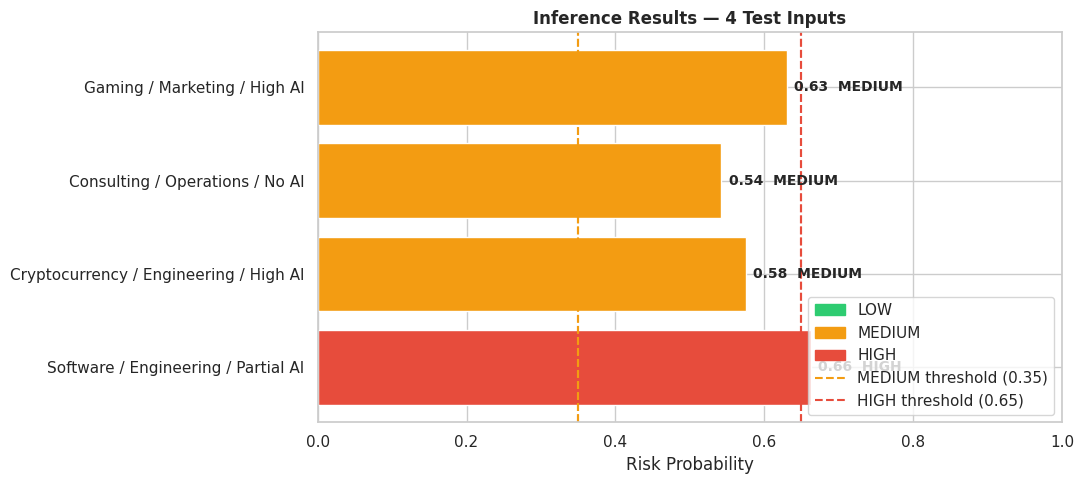

In [87]:
# ── 5.8  Visual summary ──────────────────────────────────────────────────────
labels = [r["_label"] for r in results]
probs  = [r["risk_probability"] for r in results]
colors = ["#e74c3c" if p >= 0.65 else ("#f39c12" if p >= 0.35 else "#2ecc71") for p in probs]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels, probs, color=colors, edgecolor="white")

ax.axvline(0.35, linestyle="--", color="#f39c12", linewidth=1.5, label="MEDIUM threshold (0.35)")
ax.axvline(0.65, linestyle="--", color="#e74c3c", linewidth=1.5, label="HIGH threshold (0.65)")
ax.set_xlim(0, 1)
ax.set_xlabel("Risk Probability")
ax.set_title("Inference Results — 4 Test Inputs", fontweight="bold")

for bar, prob, res in zip(bars, probs, results):
    ax.text(
        prob + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{prob:.2f}  {res['risk_label']}",
        va="center", fontsize=10, fontweight="bold"
    )

patches = [
    mpatches.Patch(color="#2ecc71", label="LOW"),
    mpatches.Patch(color="#f39c12", label="MEDIUM"),
    mpatches.Patch(color="#e74c3c", label="HIGH"),
]
ax.legend(handles=patches + [ax.axvline(0.35, linestyle="--", color="#f39c12"),
                              ax.axvline(0.65, linestyle="--", color="#e74c3c")],
          labels=["LOW", "MEDIUM", "HIGH", "MEDIUM threshold (0.35)", "HIGH threshold (0.65)"],
          loc="lower right")

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/inference_results.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

| Stage | Key output |
|---|---|
| 1. Data | 35 rows, 14 features, balanced classes (18/17) |
| 2. Training | 60/20/20 split, 4 models compared, best selected by Val AUC |
| 3. Validation | Learning curves, ROC, PR, threshold analysis, calibration |
| 4. Testing | Hold-out test AUC & AP, confusion matrix, PR curve |
| 5. Inference | `predict_layoff_risk()` loads weights from disk, returns full response |

**⚠ Data size caveat:** 35 samples means all metrics have high variance. CV AUC fold scores like `[1.0, 1.0, 1.0, 0.9]` reflect overfitting on small data — not real generalisation. Feed new data via `retrain_on_new_data()` once 500+ samples are available.